# Worksheet 3 -- Low Rank Approximations 

## Imports

In [1]:
import numpy as np
import h5py
import matplotlib.pyplot as plt

### Task 1 - Exploration and preprocessing

In [2]:
CLASS_NAMES = [
'Disturbed', 'Merging', 'Round Smooth', 'In-between Smooth',
'Cigar Smooth', 'Barred Spiral', 'Unbarred Tight Spiral',
'Unbarred Loose Spiral', 'Edge-on no Bulge', 'Edge-on with Bulge']
with h5py.File('Galaxy10_DECals_64x64.h5') as F:
    images = np.array(F['images'])
     # shape (17736, 64, 64, 3)
    labels = np.array(F['ans'])
     # integer class labels 0..9

In [3]:
#print(images)
#print(len(labels))
#plt.imshow(images[27] / 255.)

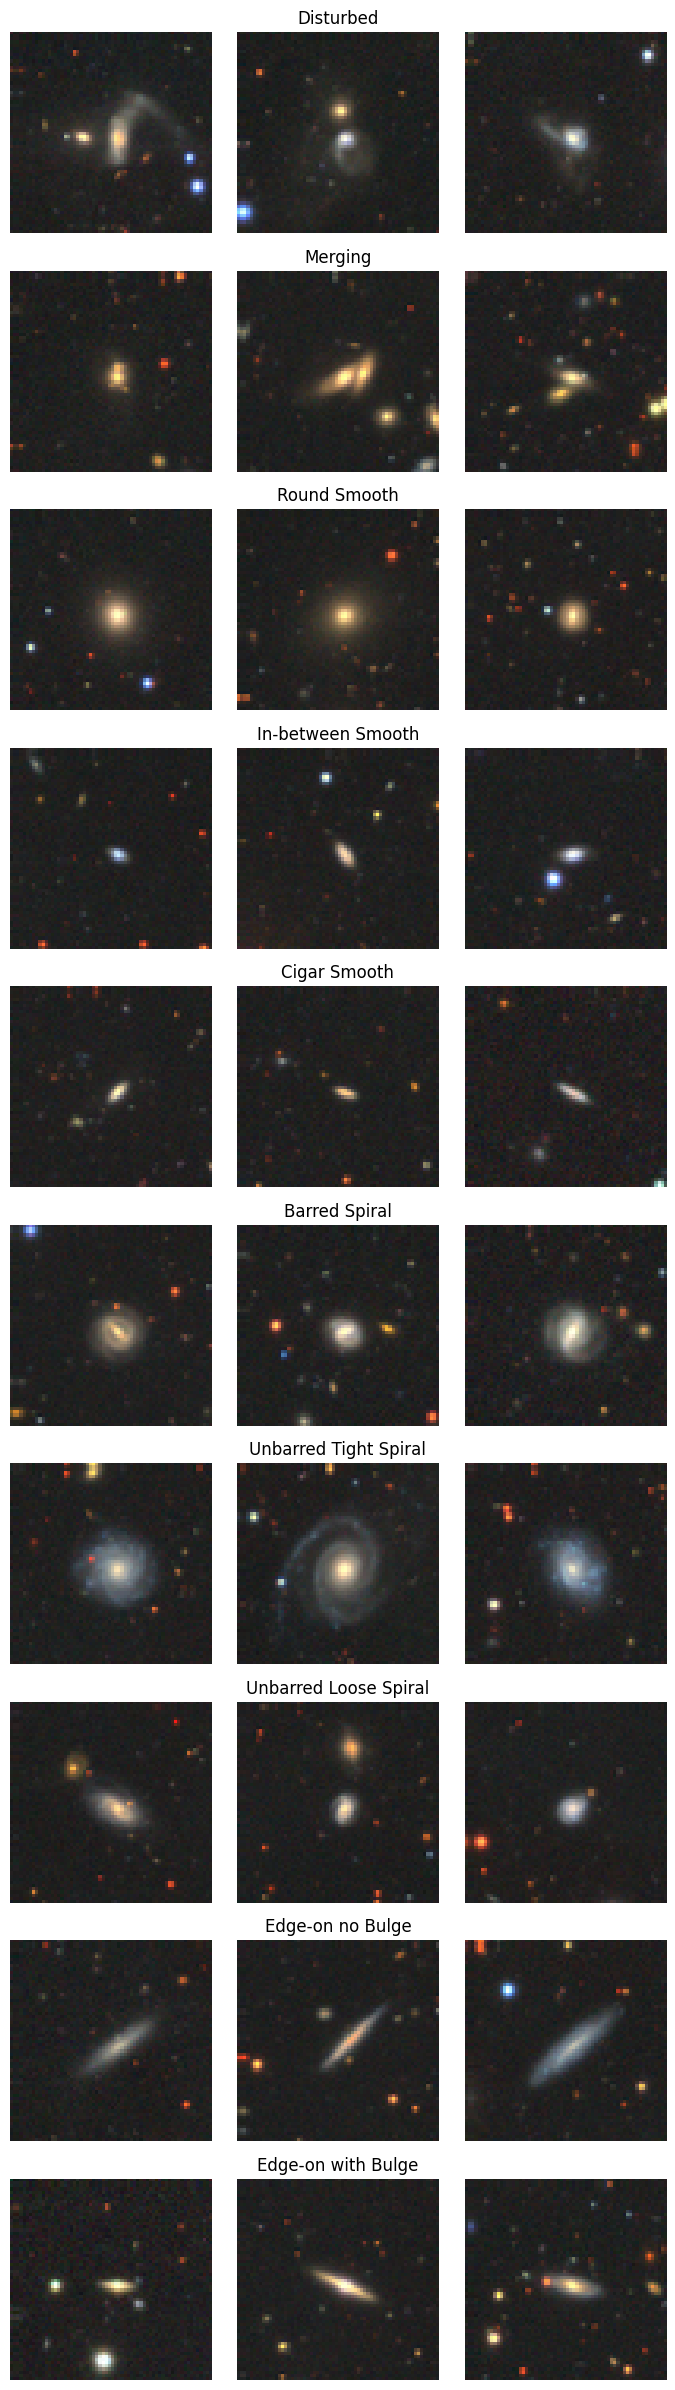

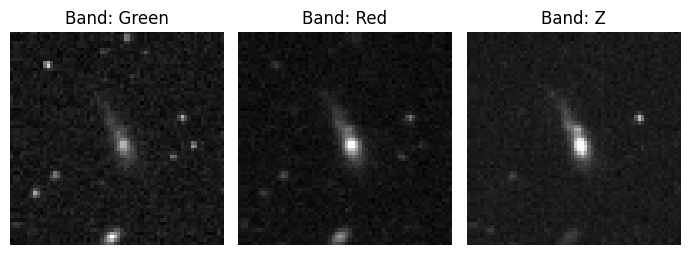

In [4]:
# For the next tasks
images_gray = images.mean(axis=-1)

fig, axes = plt.subplots(10, 3, figsize=(7, 24))
# For each class, find the first 5 examples and plot them
for class_id in range(10):
    # np.where returns indices where condition is true; [0] gets the array, [:5] takes the first 5
    idx = np.where(labels == class_id)[0][:3]
    
    # First 5 columns: RGB images
    for col, i in enumerate(idx):
        axes[class_id, col].imshow(images[i] / 255.)  # Normalize to [0,1] for display
        axes[class_id, col].axis('off')
        if col == 0:
            axes[class_id, col].set_ylabel(CLASS_NAMES[class_id], fontsize=8)

for idx, i in enumerate(CLASS_NAMES):
    axes[idx, 1].set_title(i)

plt.tight_layout()
plt.show()

# Plot of singular bands
bands = ['Green', 'Red', 'Z']
fix, axes = plt.subplots(1, 3, figsize=(7, 4))
for i in range(3):
    axes[i].imshow(images[27][:,:,i] / 255., cmap='gray')  # Show each color channel as grayscale
    axes[i].set_title(f'Band: {bands[i]}')
    axes[i].axis('off')
plt.tight_layout()
plt.show()


### Task 2 - SVD of a single image

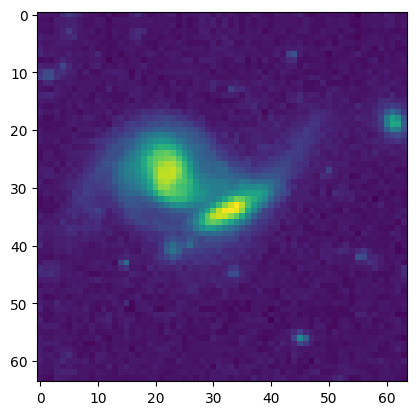

In [5]:
chosen_index = 2500
chosen_image = images_gray[chosen_index]
plt.imshow(chosen_image)

In [6]:
# From the lecture
U, S, V = np.linalg.svd(chosen_image, full_matrices=True)

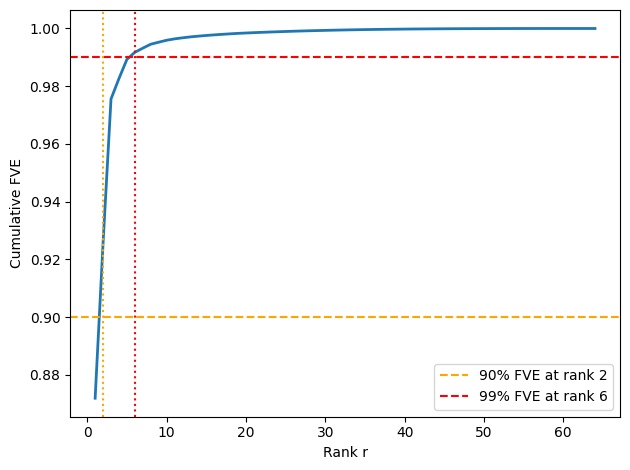

Rank needed for 90% FVE: 2
Rank needed for 99% FVE: 6


In [7]:
def reconstruct(U, S, V, r):
    # Using matrix multiplication with @
    # Taking the first r columns of U and rows of V
    return U[:, :r] @ np.diag(S[:r]) @ V[:r, :]


r_quarter = max(1, len(S) // 4)   
r_sixteenth = max(1, len(S) // 16)

img_r_quarter = reconstruct(U, S, V, r_quarter)
img_r_sixteenth = reconstruct(U, S, V, r_sixteenth)

def fve(s):
    s_sq = s**2
    # We compute the fraction for all possible ranks first, then we'll check for specific ranks afterwards.
    return np.cumsum(s_sq) / np.sum(s_sq)

# Find the ranks at which FVE first reaches 90% and 99%
r90 = np.searchsorted(fve(S), 0.90) + 1  # +1 because searchsorted is 0-indexed
r99 = np.searchsorted(fve(S), 0.99) + 1

plt.plot(np.arange(1, len(S)+1), fve(S), lw=2)
plt.axhline(0.90, color='orange', linestyle='--', label=f'90% FVE at rank {r90}')
plt.axhline(0.99, color='red',    linestyle='--', label=f'99% FVE at rank {r99}')
plt.axvline(r90, color='orange', linestyle=':')
plt.axvline(r99, color='red',    linestyle=':')
plt.xlabel('Rank r')
plt.ylabel('Cumulative FVE')
plt.legend()
plt.tight_layout()
plt.show()

print(f"Rank needed for 90% FVE: {r90}")
print(f"Rank needed for 99% FVE: {r99}")

In [8]:
# We have a 64x64 image, so beta=1.

omega = 2.858
tau = omega * np.median(S)

r_hard = np.sum(S > tau)
img_hard = reconstruct(U, S, V, r_hard)

In [9]:
print(f"Hard threshold tau = {tau:.2f}")
print(f"Hard threshold rank = {r_hard}")

Hard threshold tau = 75.39
Hard threshold rank = 11


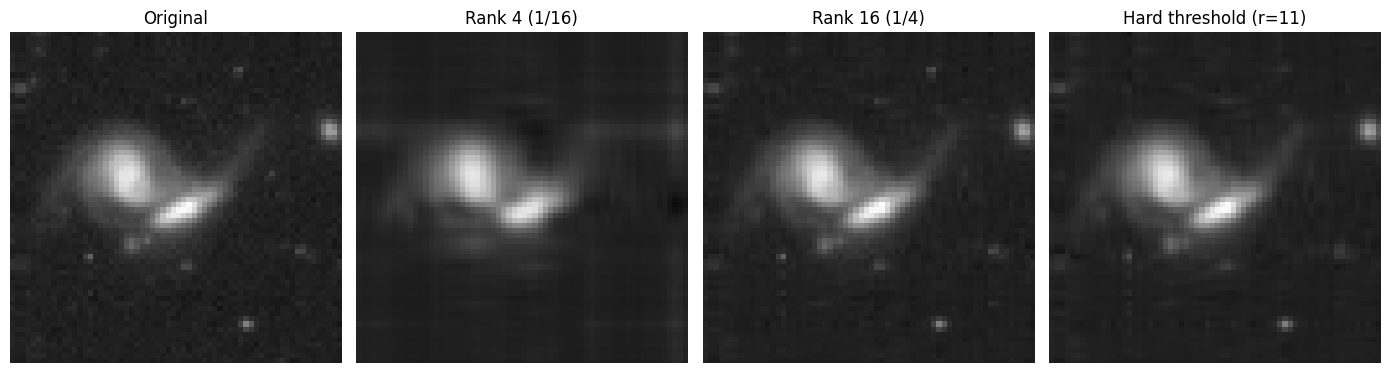

In [10]:
fig, axes = plt.subplots(1, 4, figsize=(14, 4))
titles = ['Original', f'Rank {r_sixteenth} (1/16)', f'Rank {r_quarter} (1/4)', 
          f'Hard threshold (r={r_hard})']
imgs = [chosen_image, img_r_sixteenth, img_r_quarter, img_hard]

for ax, im, title in zip(axes, imgs, titles):
    ax.imshow(im, cmap='gray', vmin=0, vmax=255)
    ax.set_title(title)
    ax.axis('off')

plt.tight_layout()
plt.savefig('task2_reconstructions.png', dpi=150)
plt.show()

### Task 3 – SVD over the full galaxy sample

In [11]:
# First we build the matrix X
N = len(images_gray)  # Number of images
n_pix = 64 * 64 # Number of pixels

X = images_gray.reshape(N, n_pix).T

X_mean = X.mean(axis=1) # Need to set axis=1 to get mean of each pixel across all images, not just one value.

X_centered = X - X_mean[:, np.newaxis] # We need to add a new axis to X_mean to make it (4096, 1) so that it can be broadcasted across all columns of X.

In [12]:
U, S, Vh = np.linalg.svd(X_centered, full_matrices=False)

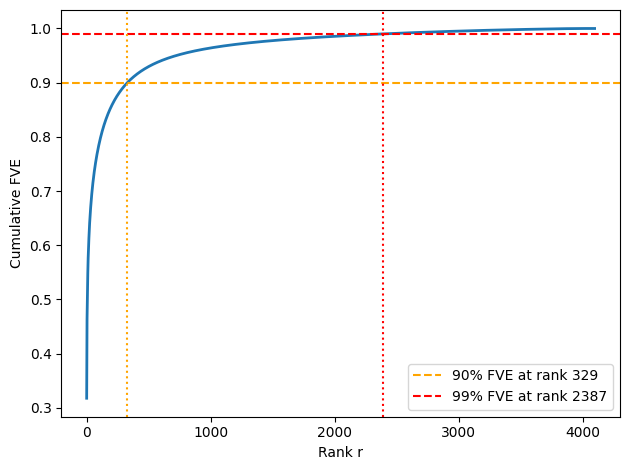

Rank needed for 90% FVE: 329
Rank needed for 99% FVE: 2387


In [13]:
# Copied from Task 2 to compute FVE and ranks for the full dataset
r90 = np.searchsorted(fve(S), 0.90) + 1  # +1 because searchsorted is 0-indexed
r99 = np.searchsorted(fve(S), 0.99) + 1

plt.plot(np.arange(1, len(S)+1), fve(S), lw=2)
plt.axhline(0.90, color='orange', linestyle='--', label=f'90% FVE at rank {r90}')
plt.axhline(0.99, color='red',    linestyle='--', label=f'99% FVE at rank {r99}')
plt.axvline(r90, color='orange', linestyle=':')
plt.axvline(r99, color='red',    linestyle=':')
plt.xlabel('Rank r')
plt.ylabel('Cumulative FVE')
plt.legend()
plt.tight_layout()
plt.show()

print(f"Rank needed for 90% FVE: {r90}")
print(f"Rank needed for 99% FVE: {r99}")

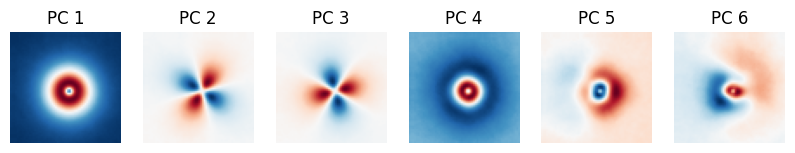

In [14]:
fig, ax = plt.subplots(1, 6, figsize=(10, 3))
for i in range(6):
    eigenimg = U[:, i].reshape(64, 64)
    # Use a diverging colormap because eigenimages have positive and negative values
    ax[i].imshow(eigenimg, cmap='RdBu_r')
    ax[i].set_title(f'PC {i+1}')
    ax[i].axis('off')

#plt.suptitle('First 6 Principal Components (Eigenimages)', fontsize=16)
#plt.tight_layout()
plt.show()

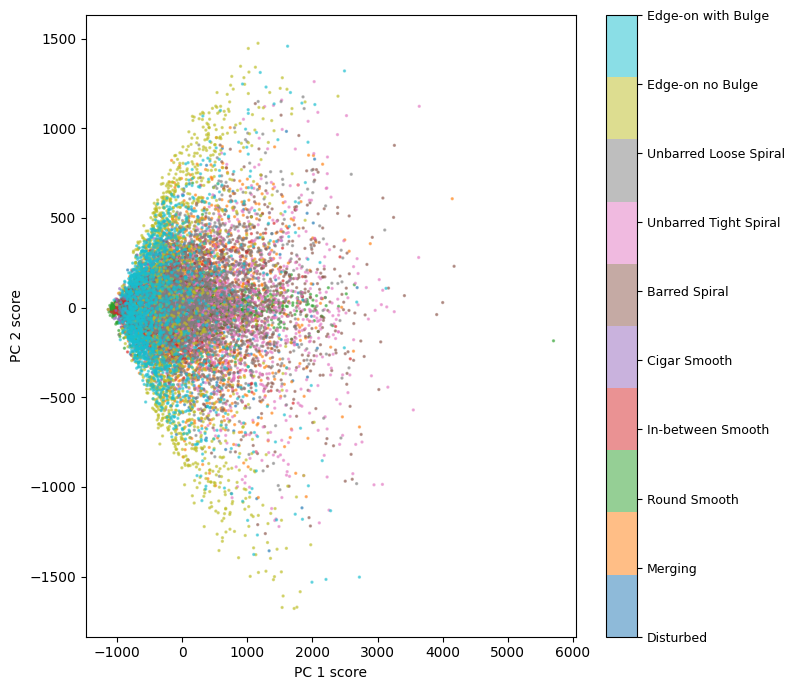

In [15]:
# The scores are the coordinates of each image in the PCA space. We can compute them by multiplying the diagonal matrix of singular values with Vh. The first two rows of the resulting matrix will give us the coordinates along the first two principal components.
scores = np.diag(S) @ Vh  

fig, ax = plt.subplots(figsize=(8, 7))
scatter = ax.scatter(scores[0, :], scores[1, :],
                     c=labels, cmap='tab10', s=2, alpha=0.5)
# Add a colorbar with class name labels
cbar = plt.colorbar(scatter, ax=ax, ticks=np.arange(10))
cbar.ax.set_yticklabels(CLASS_NAMES, fontsize=9)
ax.set_xlabel('PC 1 score')
ax.set_ylabel('PC 2 score')
plt.tight_layout()
plt.show()

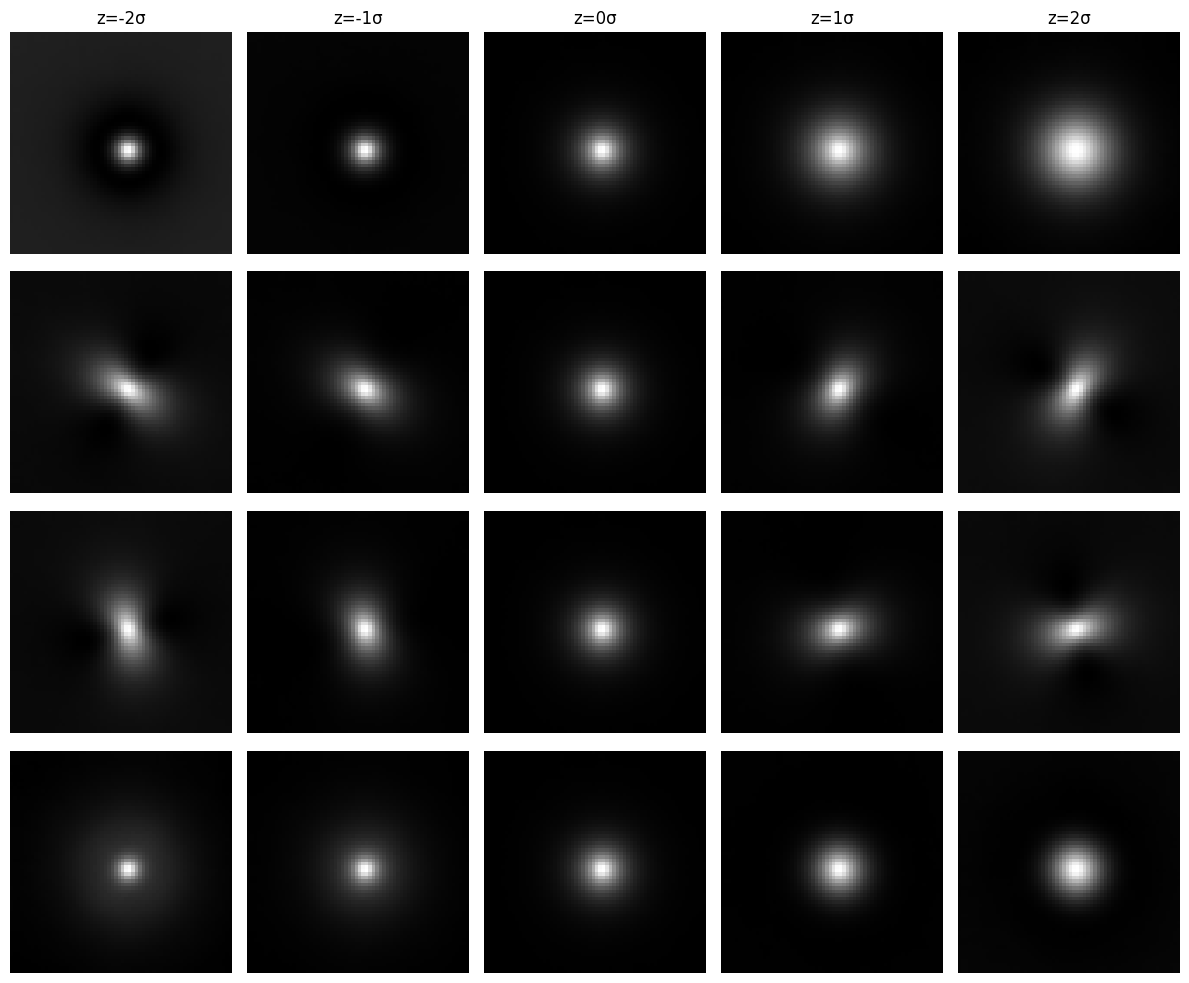

In [ ]:
# We take the first four PCs
pc_stds = scores[:4, :].std(axis=1)

sweep_values = np.array([-2, -1, 0, 1, 2])

fig, axes = plt.subplots(4, 5, figsize=(12, 10))
for pc_idx in range(4):
    for col, z_val in enumerate(sweep_values):
        # Build a coefficient vector: all zeros except pc_idx
        z = np.zeros(4)
        z[pc_idx] = z_val * pc_stds[pc_idx]  # scale by std to get "2 sigma" meaning
        
        # Reconstruct: X_hat = X_mean + sum_k z_k * U[:, k]
        # (Here z_k are the actual PC score values, not the sigma-scaled ones)

        X_hat = X_mean + U[:, :4] @ z  # We can use matrix multiplication to sum over the first 4 PCs at once
        
        axes[pc_idx, col].imshow(X_hat.reshape(64, 64), cmap='gray')
        axes[pc_idx, col].axis('off')
        if pc_idx == 0:
            axes[pc_idx, col].set_title(f'z={z_val}σ')
        if col == 0:
            axes[pc_idx, col].set_ylabel(f'PC {pc_idx+1}')

plt.tight_layout()
plt.show()